# Lab 3: Contextual Bandit-Based News Article Recommendation System

**Course:** Reinforcement Learning Fundamentals  
**Student Name:** Niyati Singh 
**Roll Number:** U20230080 
**GitHub Branch:** niyati_u20230080

**Objective:** To implement a News Recommendation System using Contextual Multi-Armed Bandits (CMAB) to recommend news articles based on user categories.

## Imports and Setup

In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from rlcmab_sampler import sampler

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


ROLL_NUMBER = 80

## Load Datasets

In [120]:
# Load datasets
news_df = pd.read_csv("data/news_articles.csv")
train_users = pd.read_csv("data/train_users.csv")
test_users = pd.read_csv("data/test_users.csv")

print(f"\nDataset Shapes:")
print(f"  • News articles: {news_df.shape}")
print(f"  • Training users: {train_users.shape}")
print(f"  • Test users: {test_users.shape}")


Dataset Shapes:
  • News articles: (209527, 6)
  • Training users: (2000, 33)
  • Test users: (2000, 32)


In [121]:
# Quick data inspection
print(f"\nNews Categories ({len(news_df['category'].unique())} total):")
print(news_df['category'].value_counts().head(10))

print(f"\nUser Label Distribution:")
print(train_users['label'].value_counts())


News Categories (42 total):
category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
Name: count, dtype: int64

User Label Distribution:
label
user_2    712
user_1    707
user_3    581
Name: count, dtype: int64


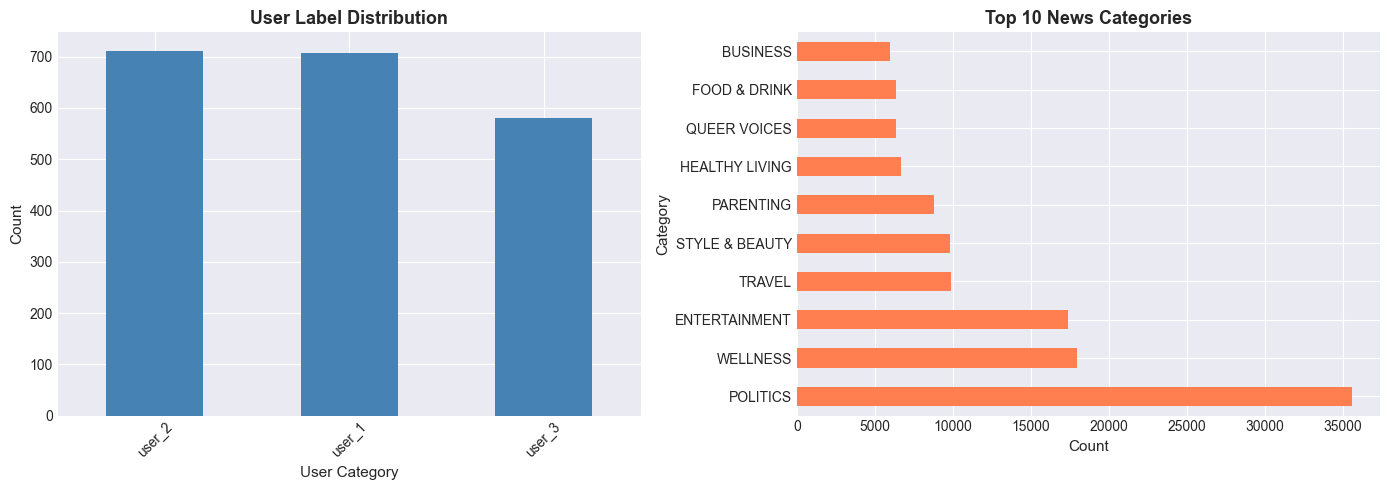

In [122]:
#Visualizing label distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#User label distribution
train_users['label'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('User Label Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('User Category', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)

#News category distribution
news_df['category'].value_counts().head(10).plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 10 News Categories', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Count', fontsize=11)
axes[1].set_ylabel('Category', fontsize=11)

plt.tight_layout()
plt.show()

In [123]:
#Checking for missing values
print("\nMissing Values Analysis:")
print(f"Training Users - Missing: {train_users.isnull().sum().sum()} values")
print(f"Test Users - Missing: {test_users.isnull().sum().sum()} values")
print(f"News Articles - Missing: {news_df.isnull().sum().sum()} values")


Missing Values Analysis:
Training Users - Missing: 698 values
Test Users - Missing: 679 values
News Articles - Missing: 57136 values


## 5.1 Data Pre-processing

In this section we:
- Handle missing values  
- Filter news articles for relevant categories (Entertainment, Education, Tech, Crime)  
- Encode categorical features  
- Prepare data for user classification

In [124]:
#Filtering Articles for target categories
target_categories = ['ENTERTAINMENT', 'EDUCATION', 'TECH', 'CRIME']
news_df_filtered = news_df[news_df['category'].isin(target_categories)].copy()
news_df_filtered.reset_index(drop=True, inplace=True)

print(f"\nFiltered Articles: {news_df_filtered.shape[0]} articles")
print(f"\nCategory Distribution:")
for cat in target_categories:
    count = (news_df_filtered['category'] == cat).sum()
    print(f"  • {cat}: {count} articles")

#User Preprocessing
def preprocess_users(df, is_training=True):
    """Enhanced preprocessing with multiple strategies"""
    df_clean = df.copy()
    
    #Standardize labels
    if 'label' in df_clean.columns:
        df_clean['label'] = df_clean['label'].str.replace('user_', 'User', regex=False).str.capitalize()
    
    #Identify numeric and categorical columns
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    if 'label' in numeric_cols:
        numeric_cols.remove('label')
    
    #Handle missing values with mean imputation
    for col in numeric_cols:
        if df_clean[col].isnull().any():
            df_clean[col].fillna(df_clean[col].mean(), inplace=True)
    
    return df_clean


Filtered Articles: 24042 articles

Category Distribution:
  • ENTERTAINMENT: 17362 articles
  • EDUCATION: 1014 articles
  • TECH: 2104 articles
  • CRIME: 3562 articles


In [125]:
#Preprocess datasets
train_users_clean = preprocess_users(train_users, is_training=True)
test_users_clean = preprocess_users(test_users, is_training=False)


print(f"User Categories: {train_users_clean['label'].unique()}")
print(f"Missing values in training data: {train_users_clean.isnull().sum().sum()}")

User Categories: ['User3' 'User2' 'User1']
Missing values in training data: 0


## 5.2 User Classification

Build a classifier to predict user category (`User1`, `User2`, `User3`) which serves as the **context** for the contextual bandit framework.

**Approach:**
- Split: 80% train, 20% validation  
- Model: **Random Forest Classifier** (ensemble method for better performance)
- Feature Scaling: StandardScaler for normalized features
- Evaluation: Classification report, confusion matrix, and 5-fold cross-validation

In [126]:
#Preparing features and target 
feature_cols = [col for col in train_users_clean.columns if col not in ['user_id', 'label']]
X = train_users_clean[feature_cols].copy()
y = train_users_clean['label'].copy()

#Encoding target variable
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

print(f"\nFeature Engineering:")
print(f"  • Total features: {len(feature_cols)}")
print(f"  • Target classes: {le_target.classes_}")


Feature Engineering:
  • Total features: 31
  • Target classes: ['User1' 'User2' 'User3']


In [127]:
#For categorical features
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
encoders = {}

X_encoded = X.copy()
X_test_final = test_users_clean[feature_cols].copy()

if len(categorical_cols) > 0:
    print(f"Encoded {len(categorical_cols)} categorical features!")
    for col in categorical_cols:
        le = LabelEncoder()
        # Combine train and test to ensure all categories are covered
        combined = pd.concat([X[col], X_test_final[col]], axis=0).astype(str)
        le.fit(combined)
        X_encoded[col] = le.transform(X[col].astype(str))
        X_test_final[col] = le.transform(X_test_final[col].astype(str))
        encoders[col] = le

Encoded 2 categorical features!


In [128]:
#Feature Scaling
scaler = StandardScaler()
numeric_features = X_encoded.select_dtypes(include=[np.number]).columns.tolist()
X_encoded[numeric_features] = scaler.fit_transform(X_encoded[numeric_features])
X_test_final[numeric_features] = scaler.transform(X_test_final[numeric_features])

# Train-Validation Split (80-20)
X_train, X_val, y_train, y_val = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nDataset Split:")
print(f"  • Training samples: {len(X_train)}")
print(f"  • Validation samples: {len(X_val)}")


Dataset Split:
  • Training samples: 1600
  • Validation samples: 400


In [129]:
# Train Random Forest Classifier!
print(f"\nTraining Random Forest Classifier...")
user_classifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
user_classifier.fit(X_train, y_train)

#Cross-validation for robust evaluation
cv_scores = cross_val_score(user_classifier, X_train, y_train, cv=5, scoring='accuracy')
print(f"\n5-Fold Cross-Validation Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

y_pred = user_classifier.predict(X_val)
val_accuracy = accuracy_score(y_val, y_pred)

#Display results
print("\n" + "=" * 70)
print("CLASSIFICATION REPORT - Random Forest")
print("=" * 70)
print(classification_report(y_val, y_pred, target_names=le_target.classes_))
print(f"\nValidation Accuracy: {val_accuracy:.4f}")
print("=" * 70)


Training Random Forest Classifier...

5-Fold Cross-Validation Scores: [0.89375  0.90625  0.90625  0.88125  0.834375]
Mean CV Accuracy: 0.8844 (+/- 0.0533)

CLASSIFICATION REPORT - Random Forest
              precision    recall  f1-score   support

       User1       0.89      0.87      0.88       142
       User2       0.98      0.88      0.93       142
       User3       0.84      0.97      0.90       116

    accuracy                           0.90       400
   macro avg       0.90      0.90      0.90       400
weighted avg       0.91      0.90      0.90       400


Validation Accuracy: 0.9000


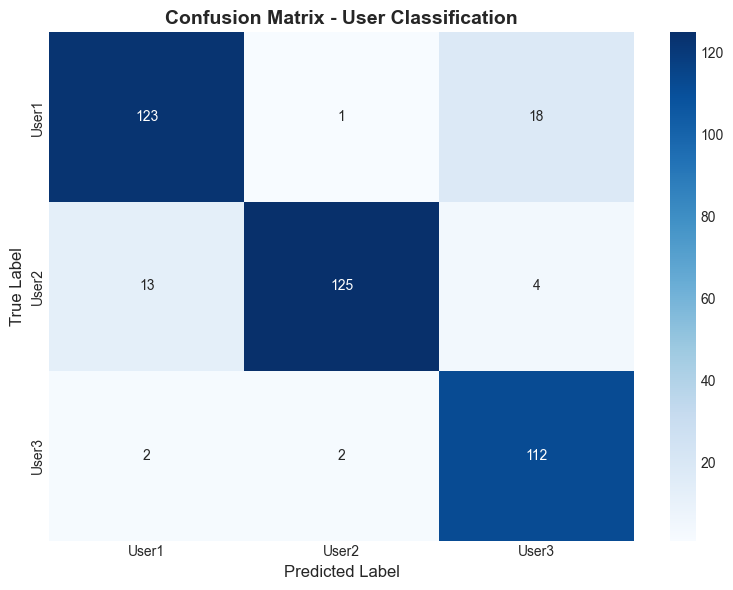

In [130]:
# Confusion Matrix Visualization
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_target.classes_, 
            yticklabels=le_target.classes_,
            ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix - User Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [131]:
# Feature Importance Analysis
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': user_classifier.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
for idx, row in feature_importance.head(10).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")


Top 10 Most Important Features:
  region_code: 0.1994
  session_duration: 0.1152
  browsing_depth: 0.1064
  scroll_activity: 0.0980
  time_on_site: 0.0656
  age: 0.0481
  content_variety: 0.0403
  interaction_count: 0.0385
  engagement_score: 0.0367
  preferred_price_range: 0.0256


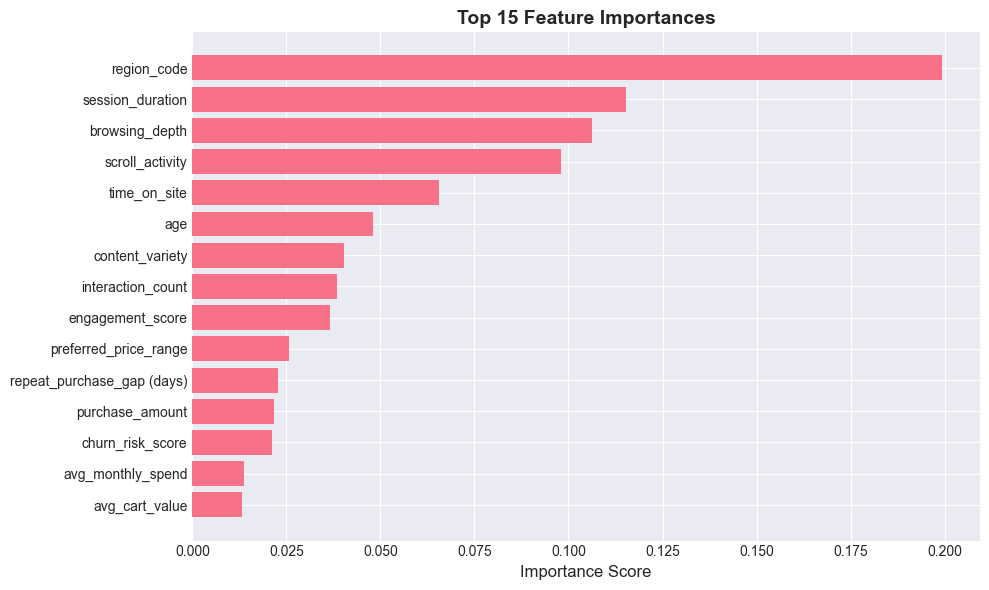

In [132]:
#Visualizing feature importance
fig, ax = plt.subplots(figsize=(10, 6))
top_features = feature_importance.head(15)
ax.barh(range(len(top_features)), top_features['importance'].values)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'].values)
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Top 15 Feature Importances', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [133]:
#Context mapping
context_mapping = {label: idx for idx, label in enumerate(le_target.classes_)}
print(f"\nContext Mapping: {context_mapping}")


Context Mapping: {'User1': 0, 'User2': 1, 'User3': 2}


## 5.3 Contextual Bandit Algorithms

### Arm Mapping

According to the assignment, the arm index `j` maps to (News Category, User Context) combinations:

| Arm Index (j) | News Category | User Context |
|---------------|---------------|--------------|
| 0–3           | Entertainment, Education, Tech, Crime | User1 |
| 4–7           | Entertainment, Education, Tech, Crime | User2 |
| 8–11          | Entertainment, Education, Tech, Crime | User3 |

In [134]:
#Category Mapping
cat_mapping = {'ENTERTAINMENT': 0, 'EDUCATION': 1, 'TECH': 2, 'CRIME': 3}
inv_cat_mapping = {v: k for k, v in cat_mapping.items()}

#Global Arm Index Function
def get_global_arm(context_idx, category_idx):
    """
    Maps (context, category) to global arm index
    context_idx: 0 (User1), 1 (User2), 2 (User3)
    category_idx: 0 (Ent), 1 (Edu), 2 (Tech), 3 (Crime)
    Returns: global arm index 0-11
    """
    return context_idx * 4 + category_idx

env_sampler = sampler(ROLL_NUMBER)
print("Reward sampler initialized successfully!")

Reward sampler initialized successfully!


### Bandit Algorithm Implementations

In [135]:
#Defining Bandit Class 
class Bandit:
    def __init__(self, n_arms=4):
        self.n = np.zeros(n_arms)  # Count of times each arm was pulled
        self.q = np.zeros(n_arms)  # Estimated reward for each arm
        
    def update(self, action, reward):
        """Update Q-value using incremental average"""
        self.n[action] += 1
        self.q[action] += (reward - self.q[action]) / self.n[action]

In [136]:
#Epsilon-Greedy Strategy
class EpsilonGreedy(Bandit):
    def __init__(self, epsilon, n_arms=4):
        super().__init__(n_arms)
        self.epsilon = epsilon
        
    def select_action(self):
        if np.random.random() < self.epsilon:
            return np.random.randint(len(self.q))  # Explore
        return np.argmax(self.q)  # Exploit

In [137]:
#Upper Confidence Bound
class UCB(Bandit):
    def __init__(self, c, n_arms=4):
        super().__init__(n_arms)
        self.c = c
        self.t = 0
        
    def select_action(self):
        self.t += 1
        #Pull each arm at least once!
        if 0 in self.n:
            return np.argmin(self.n)
        
        # UCB formula: Q(a) + c * sqrt(ln(t) / N(a))
        confidence = self.c * np.sqrt(np.log(self.t) / self.n)
        return np.argmax(self.q + confidence)

In [138]:
#SoftMax 
class SoftMax(Bandit):
    def __init__(self, temp=1.0, n_arms=4):
        super().__init__(n_arms)
        self.temp = temp
        
    def select_action(self):
        # Softmax probability: exp(Q(a)/τ) / Σ exp(Q(a')/τ)
        exp_q = np.exp(self.q / self.temp)
        probs = exp_q / np.sum(exp_q)
        return np.random.choice(len(self.q), p=probs)

### Simulation & Evaluation

Run RL simulation for T=10,000 steps and compare different hyperparameters.

In [139]:
def run_simulation(bandit_class, param_name, param_values, T=10000):
    """
    Run contextual bandit simulation
    
    Args:
        bandit_class: Bandit class to use (EpsilonGreedy, UCB, SoftMax)
        param_name: Parameter name to vary (e.g., 'epsilon', 'c', 'temp')
        param_values: List of parameter values to test
        T: Total time steps
        
    Returns:
        results: Dict mapping param_value -> context_rewards
    """
    results = {}
    
    for val in param_values:
        print(f"Running {bandit_class.__name__} with {param_name}={val}...")
        
        # Create 3 bandit instances (one per context: User1, User2, User3)
        bandits = [bandit_class(**{param_name: val}) for _ in range(3)]
        
        # Track rewards per context
        ctx_rewards = {0: [], 1: [], 2: []}
        
        for t in range(T):
            # Simulate context arrival (uniform random across 3 user types)
            ctx_idx = np.random.randint(0, 3)
            
            # Select action using corresponding bandit
            bandit = bandits[ctx_idx]
            action = bandit.select_action()
            
            # Get reward from environment sampler
            global_arm = get_global_arm(ctx_idx, action)
            reward = env_sampler.sample(global_arm)
            
            # Update bandit
            bandit.update(action, reward)
            
            # Log reward
            ctx_rewards[ctx_idx].append(reward)
        
        results[val] = ctx_rewards
        print(f"  Completed. Total samples: {sum(len(r) for r in ctx_rewards.values())}")
        
    return results

In [140]:
def plot_avg_reward_vs_time(results, title, param_name):
    """Plot Average Reward vs Time for each context"""
    plt.figure(figsize=(14, 6))
    
    for param_val, ctx_data in results.items():
        for ctx_idx, rewards in ctx_data.items():
            if len(rewards) > 0:
                # Calculate cumulative average reward
                cumulative_avg = np.cumsum(rewards) / (np.arange(len(rewards)) + 1)
                user_label = le_target.inverse_transform([ctx_idx])[0]
                plt.plot(cumulative_avg, 
                        label=f'{param_name}={param_val}, {user_label}',
                        alpha=0.8)
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Time Steps', fontsize=12)
    plt.ylabel('Average Reward', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [141]:
def plot_hyperparameter_comparison(results, title, param_name):
    """Plot comparison of different hyperparameter values"""
    plt.figure(figsize=(12, 6))
    
    param_avg_rewards = {}
    
    for param_val, ctx_data in results.items():
        all_rewards = []
        for rewards in ctx_data.values():
            all_rewards.extend(rewards)
        
        if len(all_rewards) > 0:
            # Calculate overall average reward
            avg_reward = np.mean(all_rewards)
            param_avg_rewards[param_val] = avg_reward
    
    # Bar plot
    params = list(param_avg_rewards.keys())
    avgs = list(param_avg_rewards.values())
    
    plt.bar(range(len(params)), avgs, tick_label=[f'{param_name}={p}' for p in params],
            color=['#1f77b4', '#ff7f0e', '#2ca02c'][:len(params)])
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel(f'{param_name.capitalize()} Values', fontsize=12)
    plt.ylabel('Average Reward', fontsize=12)
    plt.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, v in enumerate(avgs):
        plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

### Experiment 1: Epsilon-Greedy

Test multiple values of ε and compare performance.

Running EpsilonGreedy with epsilon=0.01...
  Completed. Total samples: 10000
Running EpsilonGreedy with epsilon=0.1...
  Completed. Total samples: 10000
Running EpsilonGreedy with epsilon=0.2...
  Completed. Total samples: 10000


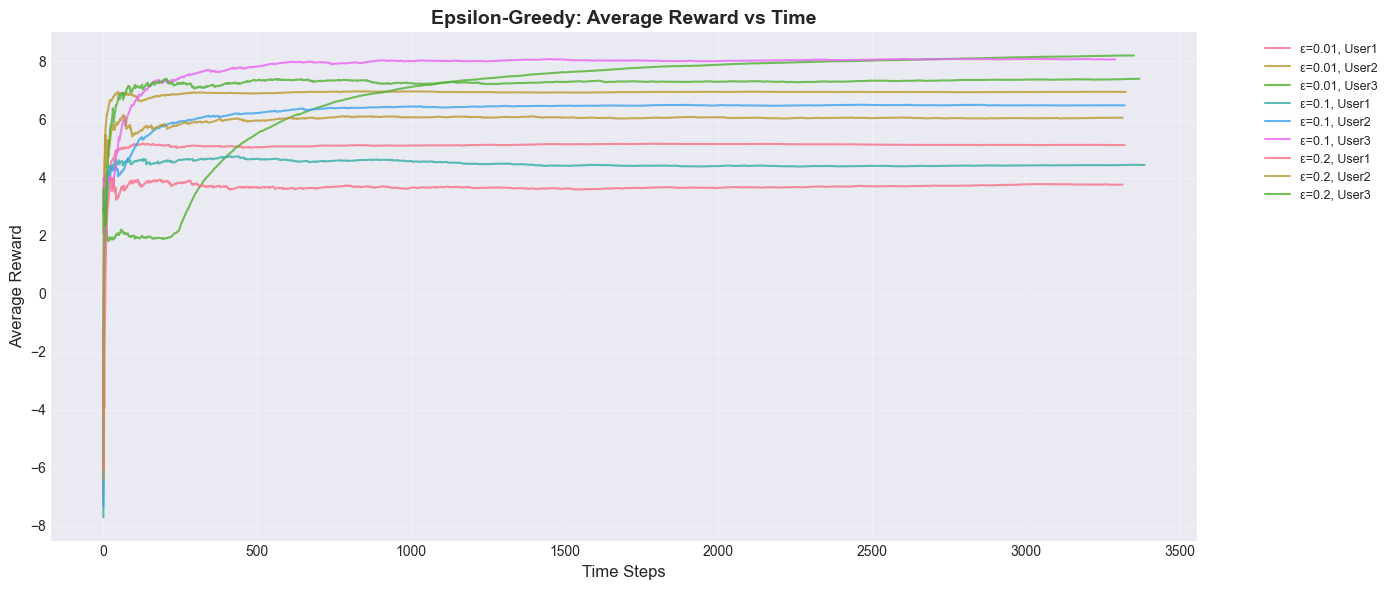

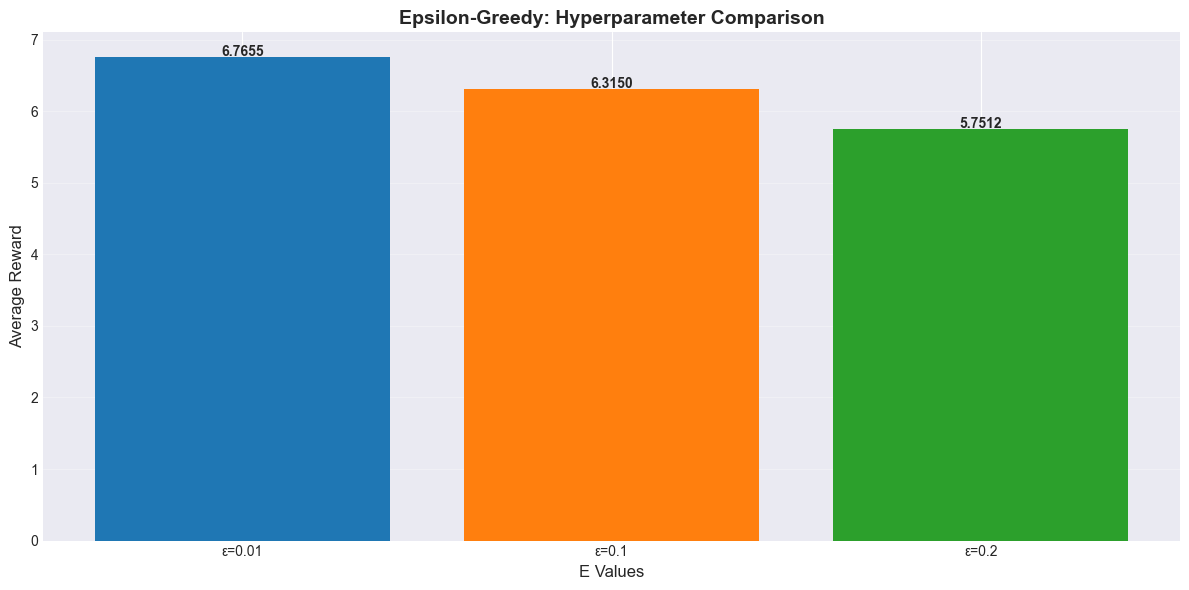

In [142]:
#Experimenting with different epsilon values
eps_values = [0.01, 0.1, 0.2]
results_eps = run_simulation(EpsilonGreedy, 'epsilon', eps_values, T=10000)

plot_avg_reward_vs_time(results_eps, 
                        "Epsilon-Greedy: Average Reward vs Time", 
                        "ε")
plot_hyperparameter_comparison(results_eps, 
                                "Epsilon-Greedy: Hyperparameter Comparison", 
                                "ε")

#### Expected Reward Distribution Analysis (Epsilon-Greedy)

In [143]:
#Extract learned Q-values (expected rewards) from trained epsilon-greedy bandits
def train_and_extract_qvalues(bandit_class, param_value, param_name, T=10000):
    """Train bandits and return the learned Q-values"""
    bandits = [bandit_class(**{param_name: param_value}) for _ in range(3)]
    
    for t in range(T):
        ctx_idx = np.random.randint(0, 3)
        action = bandits[ctx_idx].select_action()
        global_arm = get_global_arm(ctx_idx, action)
        reward = env_sampler.sample(global_arm)
        bandits[ctx_idx].update(action, reward)
    
    #Extract Q-values for each context
    q_values = np.array([bandit.q for bandit in bandits])
    return q_values, bandits

#Train epsilon-greedy models and extract expected rewards
eps_qvalues = {}
eps_bandits = {}

for eps in eps_values:
    q_vals, bandits = train_and_extract_qvalues(EpsilonGreedy, eps, 'epsilon', T=10000)
    eps_qvalues[eps] = q_vals
    eps_bandits[eps] = bandits

print("\n" + "="*80)
print("Expected Reward Distribution (Q-values) for Epsilon-Greedy")
print("="*80)

categories = ['ENTERTAINMENT', 'EDUCATION', 'TECH', 'CRIME']
user_types = le_target.classes_

for eps in eps_values:
    print(f"\n📊 ε = {eps}")
    print("-" * 80)
    q_vals = eps_qvalues[eps]
    
    df_q = pd.DataFrame(q_vals.T, 
                        columns=user_types, 
                        index=categories)
    print(df_q.round(3))
    
    #Computing statistics across contexts
    print("\n📈 Statistics Across All Contexts:")
    print(f"  Mean Expected Reward per Category:")
    for i, cat in enumerate(categories):
        mean_reward = q_vals[:, i].mean()
        std_reward = q_vals[:, i].std()
        print(f"    {cat:15s}: μ={mean_reward:7.3f}, σ={std_reward:6.3f}")
    print()



Expected Reward Distribution (Q-values) for Epsilon-Greedy

📊 ε = 0.01
--------------------------------------------------------------------------------
                User1   User2   User3
ENTERTAINMENT -7.7530 -5.1480  1.9970
EDUCATION      5.2150  6.9780 -5.5980
TECH          -2.2340  3.4090  3.9030
CRIME         -5.7440  4.6760  8.7300

📈 Statistics Across All Contexts:
  Mean Expected Reward per Category:
    ENTERTAINMENT  : μ= -3.635, σ= 4.122
    EDUCATION      : μ=  2.198, σ= 5.560
    TECH           : μ=  1.693, σ= 2.784
    CRIME          : μ=  2.554, σ= 6.097


📊 ε = 0.1
--------------------------------------------------------------------------------
                User1   User2   User3
ENTERTAINMENT -6.4700 -6.0750  2.0040
EDUCATION      5.2090  7.0120 -5.6760
TECH          -2.0240  3.8000  3.9710
CRIME         -6.0840  4.6060  8.7520

📈 Statistics Across All Contexts:
  Mean Expected Reward per Category:
    ENTERTAINMENT  : μ= -3.513, σ= 3.905
    EDUCATION      : μ=  

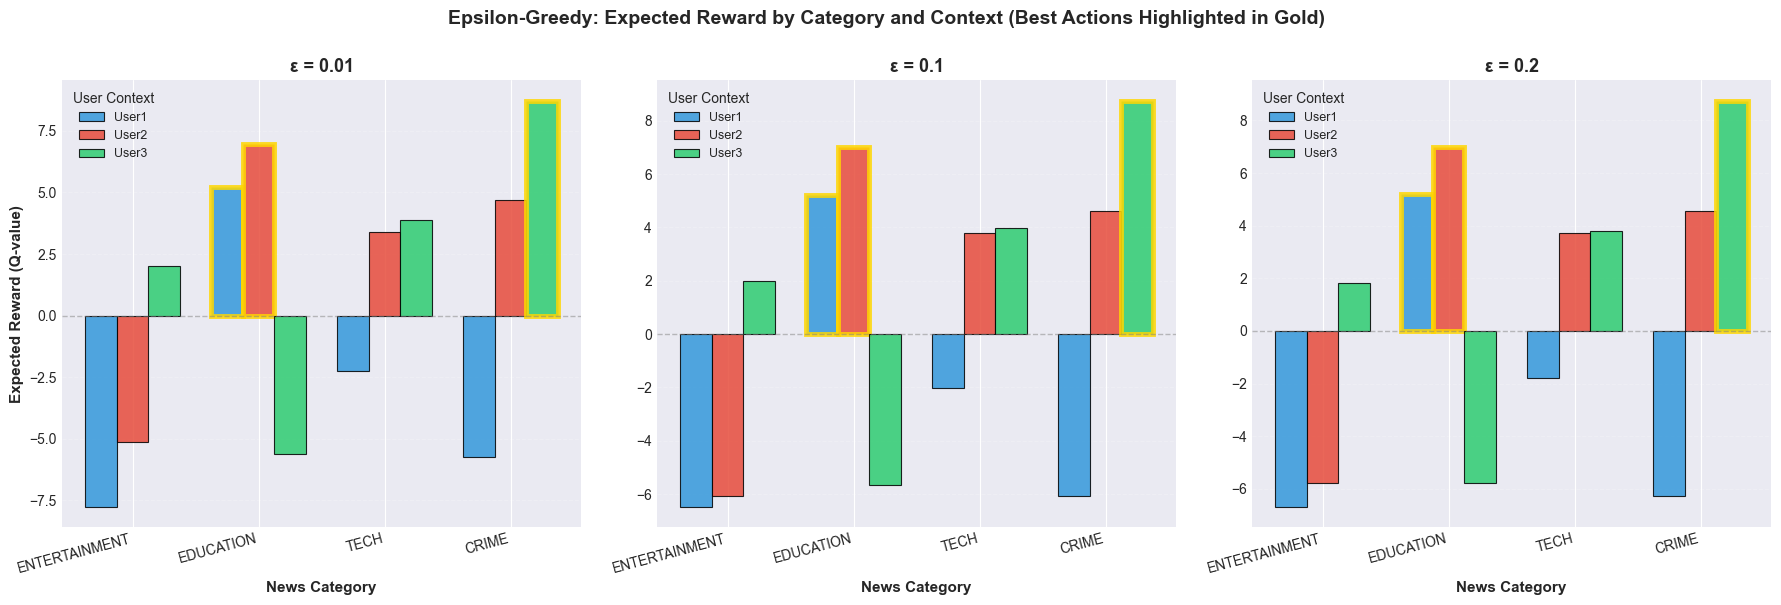

In [144]:
#Expected Reward Distribution across all contexts 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, eps in enumerate(eps_values):
    q_vals = eps_qvalues[eps]
    
    x = np.arange(len(categories))
    width = 0.25
    colors = ['#3498db','#e74c3c', '#2ecc71']
    
    for i, user in enumerate(user_types):
        offset = (i - 1) * width
        bars = axes[idx].bar(x + offset, q_vals[i], width, 
                            label=user, color=colors[i], alpha=0.85,
                            edgecolor='black', linewidth=0.8)
        
        #Highlighting best action for each context
        best_idx = np.argmax(q_vals[i])
        bars[best_idx].set_edgecolor('gold')
        bars[best_idx].set_linewidth(3.5)
    
    axes[idx].set_title(f'ε = {eps}', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('News Category', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Expected Reward (Q-value)' if idx == 0 else '', 
                        fontsize=11, fontweight='bold')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(categories, rotation=15, ha='right')
    axes[idx].legend(title='User Context', fontsize=9, title_fontsize=10)
    axes[idx].axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    axes[idx].grid(True, alpha=0.2, axis='y', linestyle='--')

plt.suptitle('Epsilon-Greedy: Expected Reward by Category and Context (Best Actions Highlighted in Gold)', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

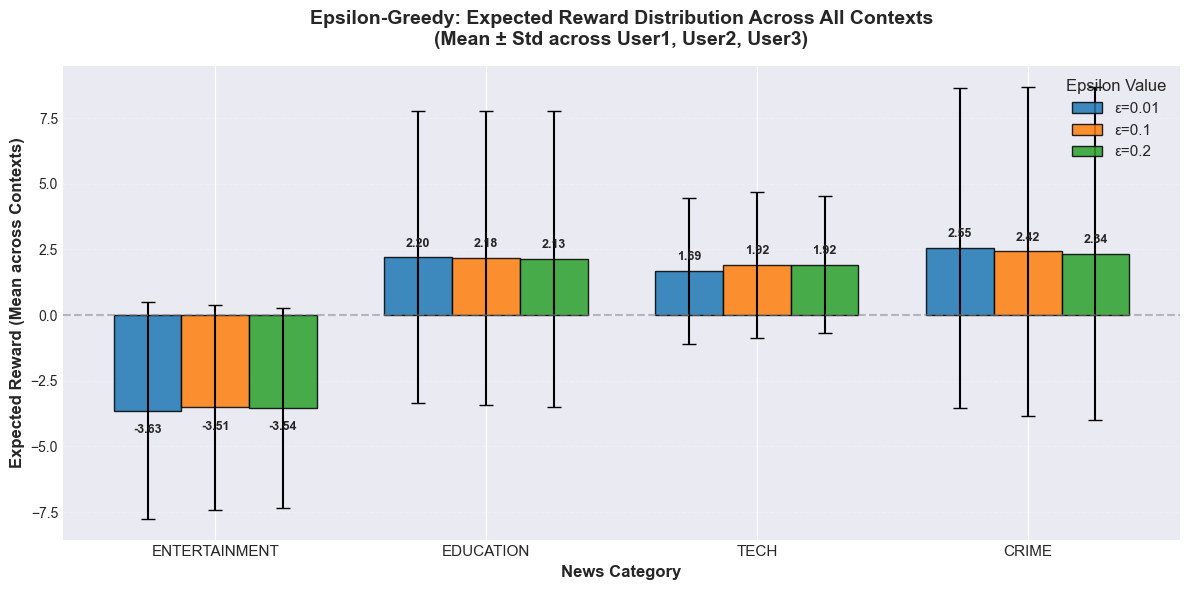

In [145]:
#Marginal Expected Reward Distribution (aggregated across contexts)
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(categories))
width = 0.25
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for idx, eps in enumerate(eps_values):
    q_vals = eps_qvalues[eps]
    
    #Computing mean expected reward across all contexts for each category
    mean_rewards = q_vals.mean(axis=0)
    std_rewards = q_vals.std(axis=0)
    
    offset = (idx - 1) * width
    bars = ax.bar(x + offset, mean_rewards, width, 
                 yerr=std_rewards, capsize=5,
                 label=f'ε={eps}', color=colors[idx], alpha=0.85,
                 edgecolor='black', linewidth=1)
    
    #Adding value labels
    for bar, val in zip(bars, mean_rewards):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.3 if height > 0 else height - 0.5,
               f'{val:.2f}', ha='center', va='bottom' if height > 0 else 'top',
               fontsize=9, fontweight='bold')

ax.set_title('Epsilon-Greedy: Expected Reward Distribution Across All Contexts\n(Mean ± Std across User1, User2, User3)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('News Category', fontsize=12, fontweight='bold')
ax.set_ylabel('Expected Reward (Mean across Contexts)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.legend(title='Epsilon Value', fontsize=11, title_fontsize=12, loc='upper right')
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1.5, alpha=0.5)
ax.grid(True, alpha=0.2, axis='y', linestyle='--')

plt.tight_layout()
plt.show()

In [146]:
#Summary Statistics
print("\n" + "="*80)
print("SUMMARY: Epsilon-Greedy Expected Reward Distribution Analysis")
print("="*80)
for eps in eps_values:
    q_vals = eps_qvalues[eps]
    print(f"\nε = {eps}:")
    print(f"  Overall Mean Expected Reward: {q_vals.mean():.3f}")
    print(f"  Overall Std Dev: {q_vals.std():.3f}")
    print(f"  Best (Context, Category): {user_types[q_vals.argmax() // 4]}, {categories[q_vals.argmax() % 4]} (Q={q_vals.max():.3f})")
    print(f"  Worst (Context, Category): {user_types[q_vals.argmin() // 4]}, {categories[q_vals.argmin() % 4]} (Q={q_vals.min():.3f})")
print("="*80)


SUMMARY: Epsilon-Greedy Expected Reward Distribution Analysis

ε = 0.01:
  Overall Mean Expected Reward: 0.703
  Overall Std Dev: 5.438
  Best (Context, Category): User3, CRIME (Q=8.730)
  Worst (Context, Category): User1, ENTERTAINMENT (Q=-7.753)

ε = 0.1:
  Overall Mean Expected Reward: 0.752
  Overall Std Dev: 5.428
  Best (Context, Category): User3, CRIME (Q=8.752)
  Worst (Context, Category): User1, ENTERTAINMENT (Q=-6.470)

ε = 0.2:
  Overall Mean Expected Reward: 0.714
  Overall Std Dev: 5.418
  Best (Context, Category): User3, CRIME (Q=8.751)
  Worst (Context, Category): User1, ENTERTAINMENT (Q=-6.671)


### Experiment 2: Upper Confidence Bound (UCB)

Test multiple values of exploration parameter C.

Running UCB with c=1.0...
  Completed. Total samples: 10000
Running UCB with c=2.0...
  Completed. Total samples: 10000
Running UCB with c=4.0...
  Completed. Total samples: 10000


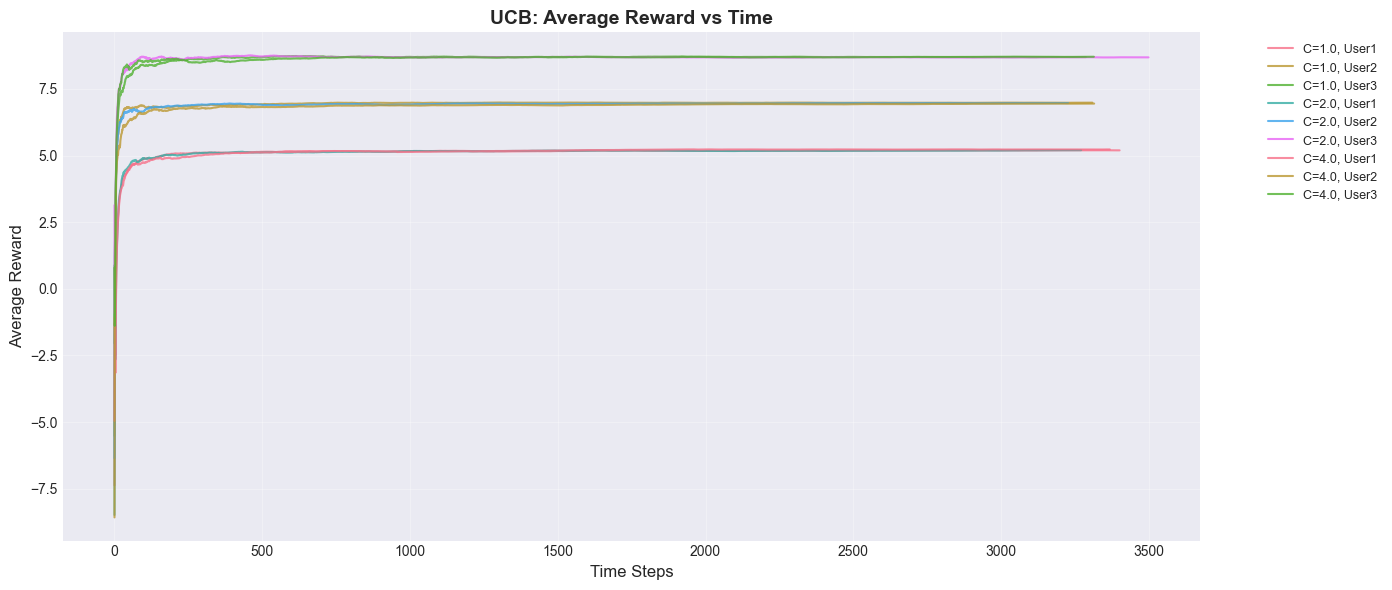

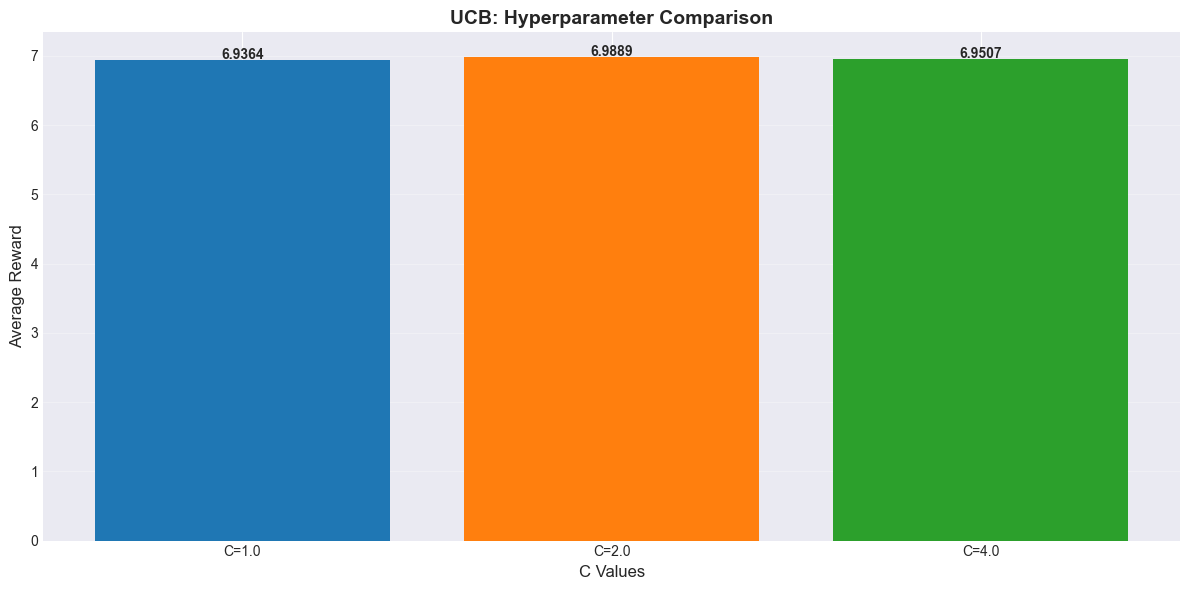

In [147]:
#Experimenting with different C values
ucb_values = [1.0, 2.0, 4.0]
results_ucb = run_simulation(UCB, 'c', ucb_values, T=10000)

#Plotting results
plot_avg_reward_vs_time(results_ucb, 
                        "UCB: Average Reward vs Time", 
                        "C")
plot_hyperparameter_comparison(results_ucb, 
                                "UCB: Hyperparameter Comparison", 
                                "C")

#### Expected Reward Distribution Analysis (UCB)

In [148]:
#Training UCB models and extract expected rewards
ucb_qvalues = {}
ucb_bandits = {}

for c in ucb_values:
    q_vals, bandits = train_and_extract_qvalues(UCB, c, 'c', T=10000)
    ucb_qvalues[c] = q_vals
    ucb_bandits[c] = bandits

print("\n" + "="*80)
print("Expected Reward Distribution (Q-values) for UCB")
print("="*80)

for c in ucb_values:
    print(f"\n📊 C = {c}")
    print("-" * 80)
    q_vals = ucb_qvalues[c]
    
    df_q = pd.DataFrame(q_vals.T, 
                        columns=user_types, 
                        index=categories)
    print(df_q.round(3))
    
    print("\n📈 Statistics Across All Contexts:")
    print(f"  Mean Expected Reward per Category:")
    for i, cat in enumerate(categories):
        mean_reward = q_vals[:, i].mean()
        std_reward = q_vals[:, i].std()
        print(f"    {cat:15s}: μ={mean_reward:7.3f}, σ={std_reward:6.3f}")
    print()

print("="*80)


Expected Reward Distribution (Q-values) for UCB

📊 C = 1.0
--------------------------------------------------------------------------------
                User1   User2   User3
ENTERTAINMENT -6.4190 -6.7250  1.3650
EDUCATION      5.1860  6.9790 -5.8170
TECH          -0.8320  0.8480  4.1850
CRIME         -7.1240  3.9270  8.7100

📈 Statistics Across All Contexts:
  Mean Expected Reward per Category:
    ENTERTAINMENT  : μ= -3.926, σ= 3.744
    EDUCATION      : μ=  2.116, σ= 5.657
    TECH           : μ=  1.400, σ= 2.085
    CRIME          : μ=  1.838, σ= 6.631


📊 C = 2.0
--------------------------------------------------------------------------------
                User1   User2   User3
ENTERTAINMENT -5.8570 -5.4570  0.4450
EDUCATION      5.2220  6.9580 -5.0450
TECH          -4.5750  3.9770  4.3540
CRIME         -8.4950  3.4260  8.7060

📈 Statistics Across All Contexts:
  Mean Expected Reward per Category:
    ENTERTAINMENT  : μ= -3.623, σ= 2.881
    EDUCATION      : μ=  2.378, σ= 5.

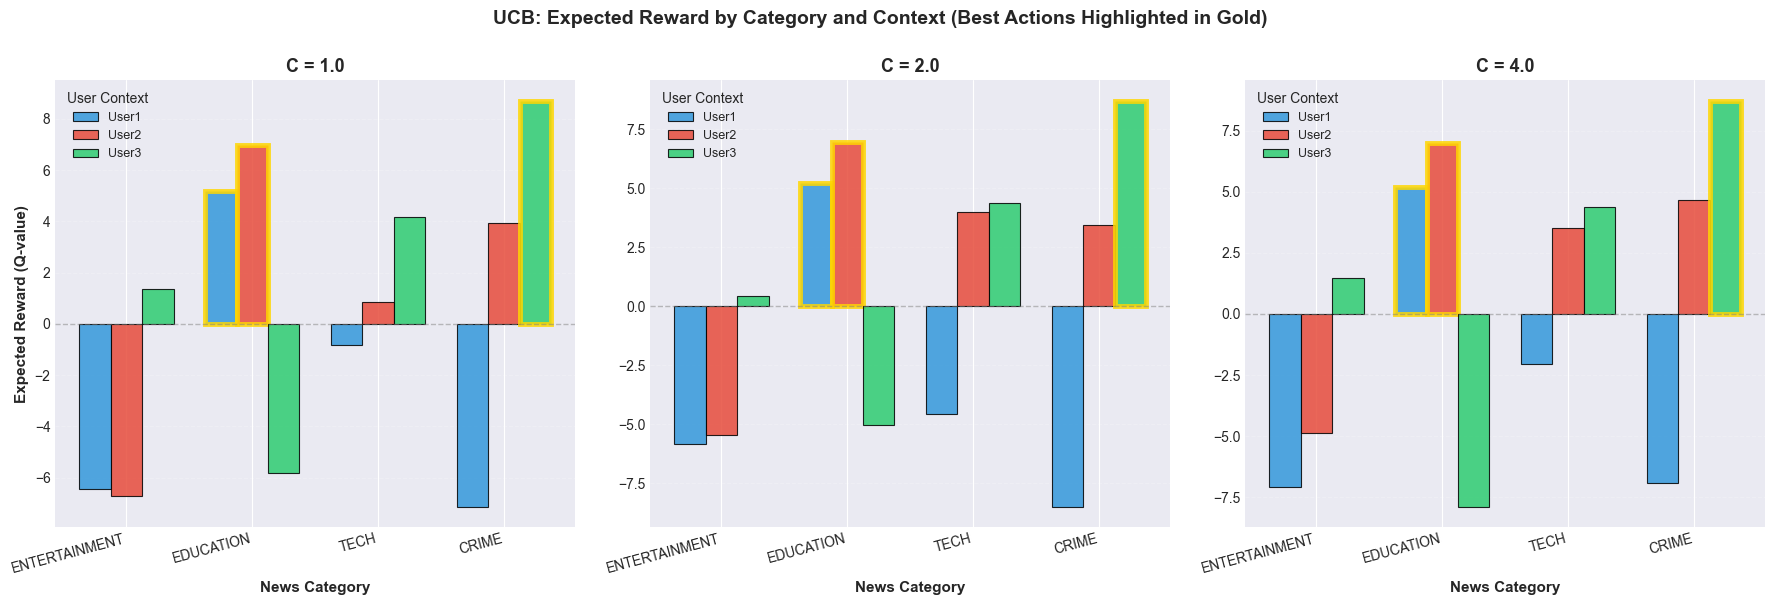

In [149]:
#Expected Reward Distribution across all contexts (UCB)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, c in enumerate(ucb_values):
    q_vals = ucb_qvalues[c]
    
    x = np.arange(len(categories))
    width = 0.25
    colors = ['#3498db', '#e74c3c', '#2ecc71']
    
    for i, user in enumerate(user_types):
        offset = (i - 1) * width
        bars = axes[idx].bar(x + offset, q_vals[i], width, 
                            label=user, color=colors[i], alpha=0.85,
                            edgecolor='black', linewidth=0.8)
        
        #Highlighting best action for each context
        best_idx = np.argmax(q_vals[i])
        bars[best_idx].set_edgecolor('gold')
        bars[best_idx].set_linewidth(3.5)
    
    axes[idx].set_title(f'C = {c}', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('News Category', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Expected Reward (Q-value)' if idx == 0 else '', 
                        fontsize=11, fontweight='bold')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(categories, rotation=15, ha='right')
    axes[idx].legend(title='User Context', fontsize=9, title_fontsize=10)
    axes[idx].axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    axes[idx].grid(True, alpha=0.2, axis='y', linestyle='--')

plt.suptitle('UCB: Expected Reward by Category and Context (Best Actions Highlighted in Gold)', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

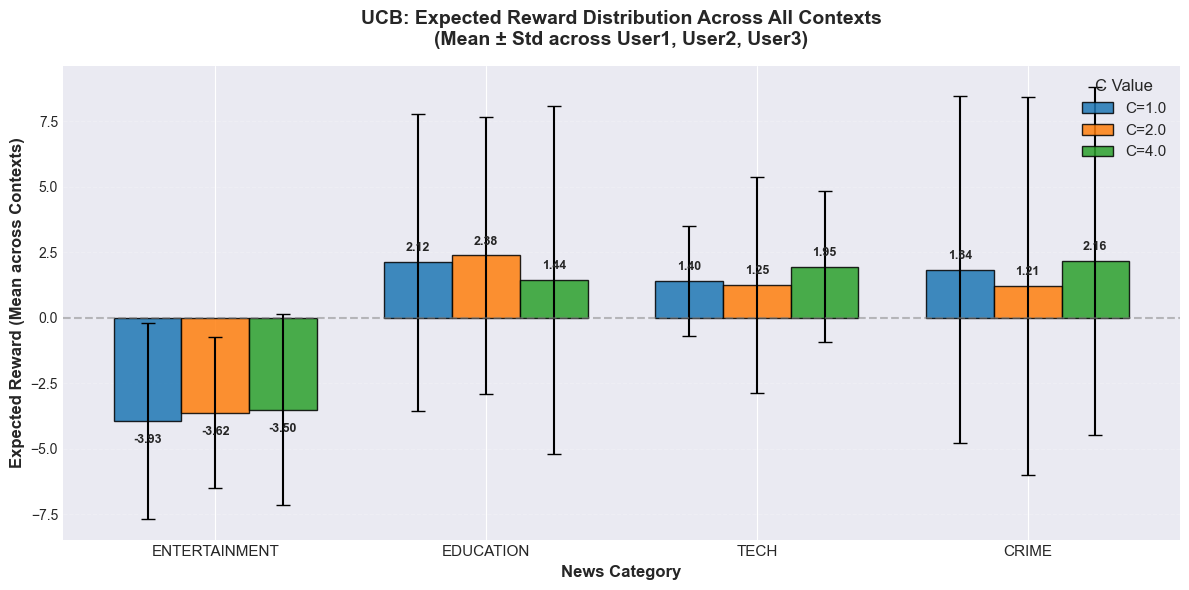


SUMMARY: UCB Expected Reward Distribution Analysis

C = 1.0:
  Overall Mean Expected Reward: 0.357
  Overall Std Dev: 5.456
  Best (Context, Category): User3, CRIME (Q=8.710)
  Worst (Context, Category): User1, CRIME (Q=-7.124)

C = 2.0:
  Overall Mean Expected Reward: 0.305
  Overall Std Dev: 5.625
  Best (Context, Category): User3, CRIME (Q=8.706)
  Worst (Context, Category): User1, CRIME (Q=-8.495)

C = 4.0:
  Overall Mean Expected Reward: 0.515
  Overall Std Dev: 5.723
  Best (Context, Category): User3, CRIME (Q=8.731)
  Worst (Context, Category): User3, EDUCATION (Q=-7.883)


In [150]:
#Marginal Expected Reward Distribution (aggregated across contexts)
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(categories))
width = 0.25
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for idx, c in enumerate(ucb_values):
    q_vals = ucb_qvalues[c]
    
    #Computing mean expected reward across all contexts for each category
    mean_rewards = q_vals.mean(axis=0)
    std_rewards = q_vals.std(axis=0)
    
    offset = (idx - 1) * width
    bars = ax.bar(x + offset, mean_rewards, width, 
                 yerr=std_rewards, capsize=5,
                 label=f'C={c}', color=colors[idx], alpha=0.85,
                 edgecolor='black', linewidth=1)
    
    for bar, val in zip(bars, mean_rewards):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.3 if height > 0 else height - 0.5,
               f'{val:.2f}', ha='center', va='bottom' if height > 0 else 'top',
               fontsize=9, fontweight='bold')

ax.set_title('UCB: Expected Reward Distribution Across All Contexts\n(Mean ± Std across User1, User2, User3)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('News Category', fontsize=12, fontweight='bold')
ax.set_ylabel('Expected Reward (Mean across Contexts)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.legend(title='C Value', fontsize=11, title_fontsize=12, loc='upper right')
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1.5, alpha=0.5)
ax.grid(True, alpha=0.2, axis='y', linestyle='--')

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*80)
print("SUMMARY: UCB Expected Reward Distribution Analysis")
print("="*80)
for c in ucb_values:
    q_vals = ucb_qvalues[c]
    print(f"\nC = {c}:")
    print(f"  Overall Mean Expected Reward: {q_vals.mean():.3f}")
    print(f"  Overall Std Dev: {q_vals.std():.3f}")
    print(f"  Best (Context, Category): {user_types[q_vals.argmax() // 4]}, {categories[q_vals.argmax() % 4]} (Q={q_vals.max():.3f})")
    print(f"  Worst (Context, Category): {user_types[q_vals.argmin() // 4]}, {categories[q_vals.argmin() % 4]} (Q={q_vals.min():.3f})")
print("="*80)

### Experiment 3: SoftMax

Use fixed temperature parameter τ = 1.

Running SoftMax with temp=1.0...
  Completed. Total samples: 10000


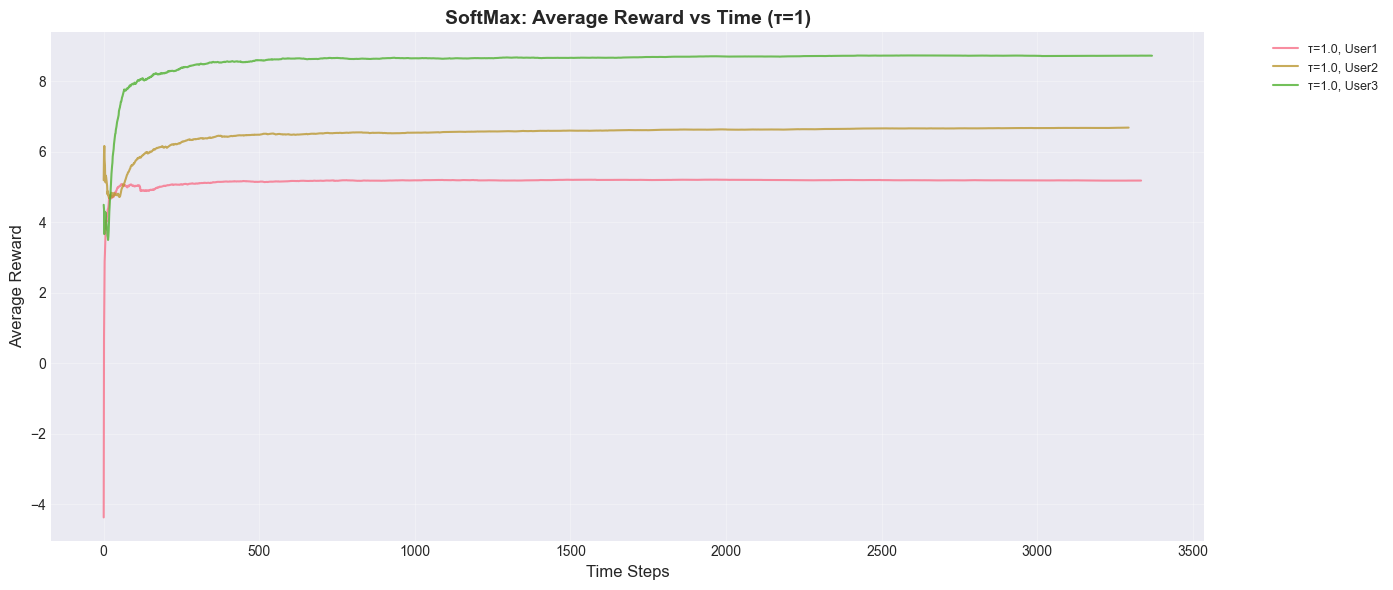

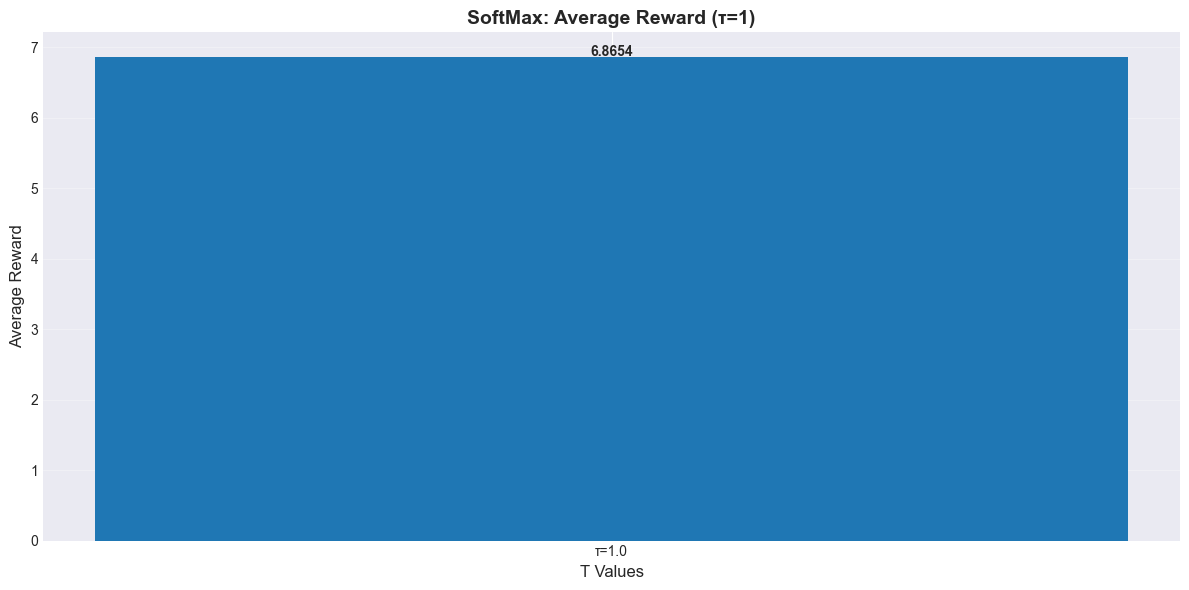

In [151]:
#Running SoftMax with τ=1
results_soft = run_simulation(SoftMax, 'temp', [1.0], T=10000)

plot_avg_reward_vs_time(results_soft, 
                        "SoftMax: Average Reward vs Time (τ=1)", 
                        "τ")
plot_hyperparameter_comparison(results_soft, 
                                "SoftMax: Average Reward (τ=1)", 
                                "τ")

#### Expected Reward Distribution Analysis (SoftMax)

In [152]:
#Using τ=1 as specified
softmax_temp = 1.0
q_vals, bandits = train_and_extract_qvalues(SoftMax, softmax_temp, 'temp', T=10000)
softmax_qvalues = q_vals
softmax_bandits = bandits

print("\n" + "="*80)
print("Expected Reward Distribution (Q-values) for SoftMax (τ=1)")
print("="*80)

print(f"\n📊 τ = {softmax_temp}")
print("-" * 80)

df_q = pd.DataFrame(q_vals.T, 
                    columns=user_types, 
                    index=categories)
print(df_q.round(3))

#Computing statistics across contexts
print("\n📈 Statistics Across All Contexts:")
print(f"  Mean Expected Reward per Category:")
for i, cat in enumerate(categories):
    mean_reward = q_vals[:, i].mean()
    std_reward = q_vals[:, i].std()
    print(f"    {cat:15s}: μ={mean_reward:7.3f}, σ={std_reward:6.3f}")

print("\n" + "="*80)


Expected Reward Distribution (Q-values) for SoftMax (τ=1)

📊 τ = 1.0
--------------------------------------------------------------------------------
                User1   User2   User3
ENTERTAINMENT -6.6200 -6.5080  1.9590
EDUCATION      5.2120  6.9700 -5.9360
TECH          -4.3490  3.8290  3.7100
CRIME         -8.7390  4.5110  8.7870

📈 Statistics Across All Contexts:
  Mean Expected Reward per Category:
    ENTERTAINMENT  : μ= -3.723, σ= 4.018
    EDUCATION      : μ=  2.082, σ= 5.715
    TECH           : μ=  1.064, σ= 3.828
    CRIME          : μ=  1.520, σ= 7.461



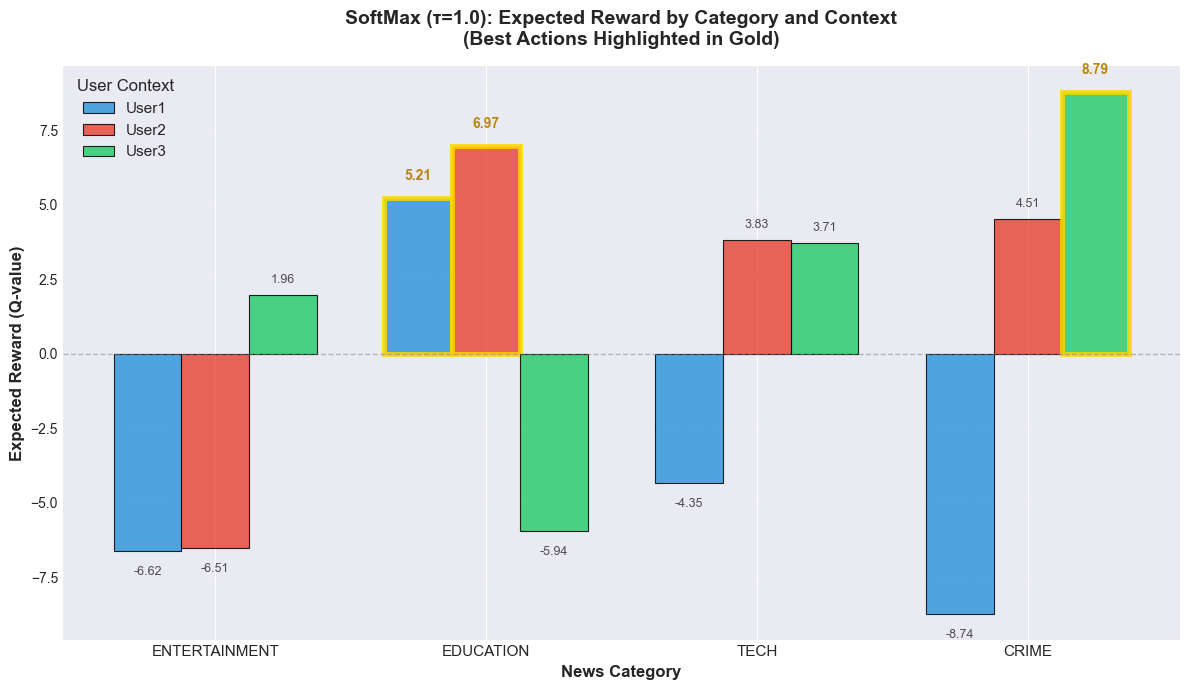

In [153]:
#Expected Reward Distribution by Context and Category
fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(categories))
width = 0.25
colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, user in enumerate(user_types):
    offset = (i - 1) * width
    bars = ax.bar(x + offset, softmax_qvalues[i], width, 
                  label=user, color=colors[i], alpha=0.85,
                  edgecolor='black', linewidth=0.8)
    
    #Highlighting best action for each context
    best_idx = np.argmax(softmax_qvalues[i])
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(3.5)
    
    for j, (bar, val) in enumerate(zip(bars, softmax_qvalues[i])):
        if j == best_idx:
            ax.text(bar.get_x() + bar.get_width()/2., val + 0.5,
                   f'{val:.2f}', ha='center', va='bottom', 
                   fontsize=10, fontweight='bold', color='darkgoldenrod')
        else:
            ax.text(bar.get_x() + bar.get_width()/2., val + 0.3 if val > 0 else val - 0.5,
                   f'{val:.2f}', ha='center', va='bottom' if val > 0 else 'top',
                   fontsize=9, alpha=0.8)

ax.set_title(f'SoftMax (τ={softmax_temp}): Expected Reward by Category and Context\n(Best Actions Highlighted in Gold)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('News Category', fontsize=12, fontweight='bold')
ax.set_ylabel('Expected Reward (Q-value)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.legend(title='User Context', fontsize=11, title_fontsize=12)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.grid(True, alpha=0.2, axis='y', linestyle='--')

plt.tight_layout()
plt.show()

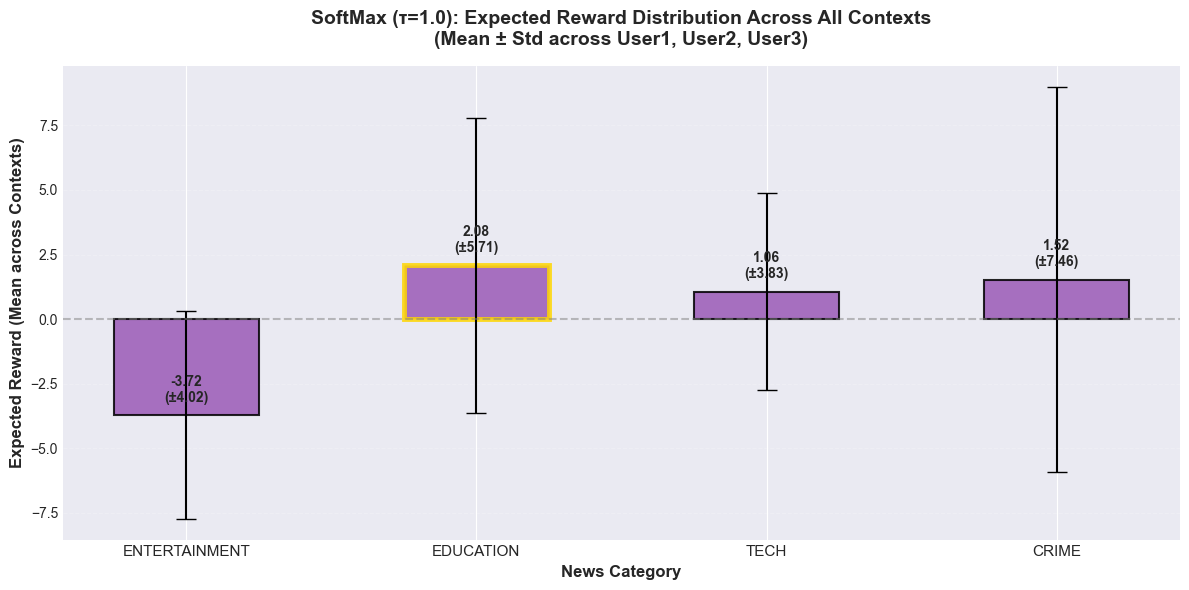

In [154]:
#Marginal Expected Reward Distribution (aggregated across contexts)
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(categories))
width = 0.5

#Compute mean expected reward across all contexts for each category
mean_rewards = softmax_qvalues.mean(axis=0)
std_rewards = softmax_qvalues.std(axis=0)

bars = ax.bar(x, mean_rewards, width, 
             yerr=std_rewards, capsize=7,
             color='#9b59b6', alpha=0.85,
             edgecolor='black', linewidth=1.5)

#Adding value labels
for bar, val, std in zip(bars, mean_rewards, std_rewards):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.4,
           f'{val:.2f}\n(±{std:.2f})', ha='center', va='bottom',
           fontsize=10, fontweight='bold')
    
#Highlighting the best overall category
best_cat_idx = np.argmax(mean_rewards)
bars[best_cat_idx].set_edgecolor('gold')
bars[best_cat_idx].set_linewidth(3.5)

ax.set_title(f'SoftMax (τ={softmax_temp}): Expected Reward Distribution Across All Contexts\n(Mean ± Std across User1, User2, User3)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('News Category', fontsize=12, fontweight='bold')
ax.set_ylabel('Expected Reward (Mean across Contexts)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1.5, alpha=0.5)
ax.grid(True, alpha=0.2, axis='y', linestyle='--')

plt.tight_layout()
plt.show()

In [155]:
# Summary Statistics and Best Actions
print("\n" + "="*80)
print(f"SUMMARY: SoftMax (τ={softmax_temp}) Expected Reward Distribution Analysis")
print("="*80)

q_vals = softmax_qvalues
print(f"\nOverall Statistics:")
print(f"  Overall Mean Expected Reward: {q_vals.mean():.3f}")
print(f"  Overall Std Dev: {q_vals.std():.3f}")
print(f"  Best (Context, Category): {user_types[q_vals.argmax() // 4]}, {categories[q_vals.argmax() % 4]} (Q={q_vals.max():.3f})")
print(f"  Worst (Context, Category): {user_types[q_vals.argmin() // 4]}, {categories[q_vals.argmin() % 4]} (Q={q_vals.min():.3f})")


SUMMARY: SoftMax (τ=1.0) Expected Reward Distribution Analysis

Overall Statistics:
  Overall Mean Expected Reward: 0.236
  Overall Std Dev: 5.927
  Best (Context, Category): User3, CRIME (Q=8.787)
  Worst (Context, Category): User1, CRIME (Q=-8.739)


## Selecting Best Algorithm 

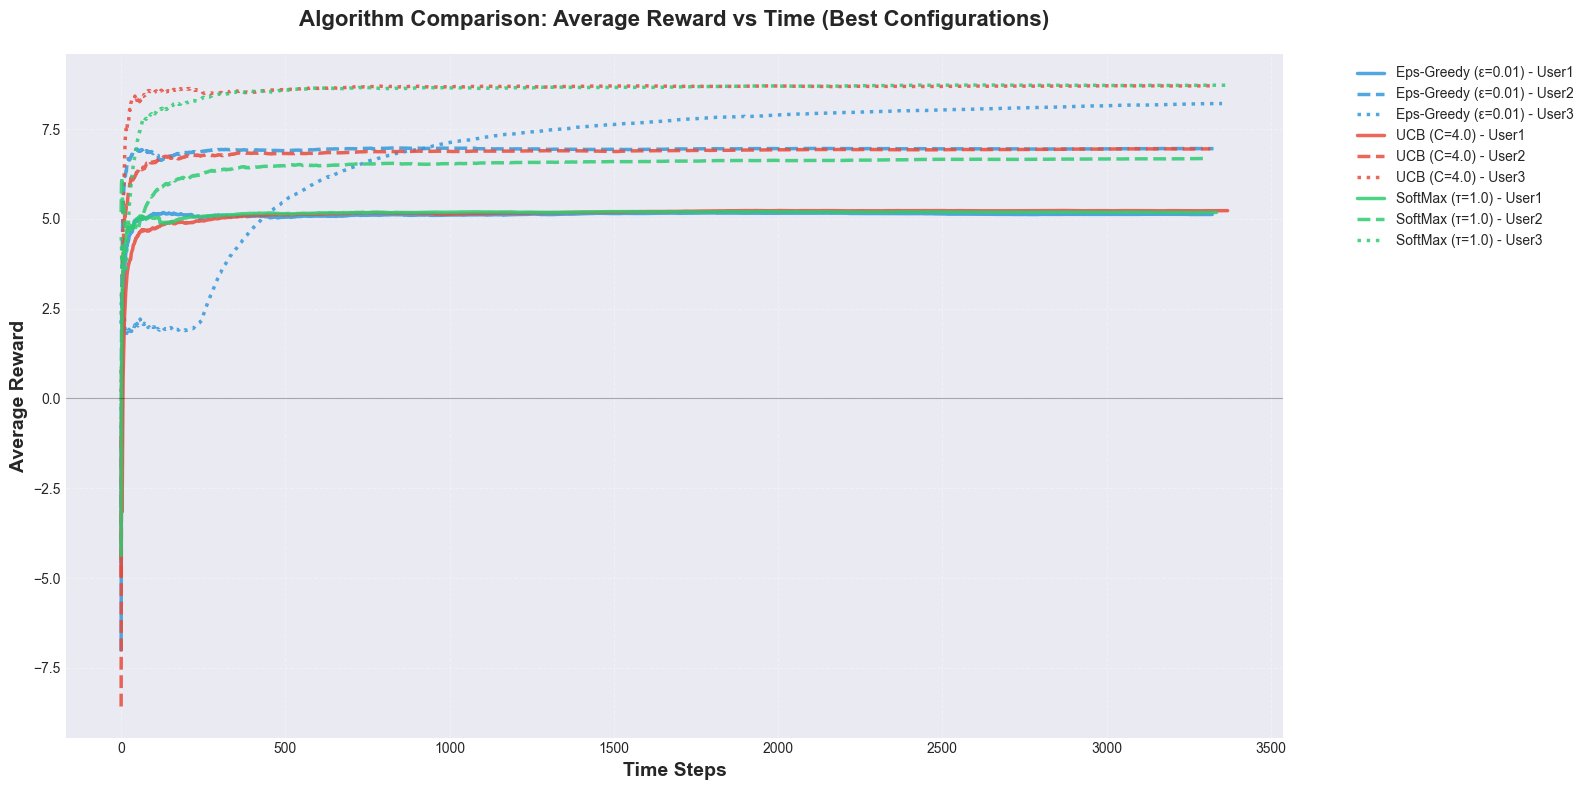

In [156]:
#Comparative Plot 1: Average Reward vs Time for Best Configurations
fig, ax = plt.subplots(figsize=(16, 8))

colors_algo = {
    'Epsilon-Greedy': '#3498db',
    'UCB': '#e74c3c', 
    'SoftMax': '#2ecc71'
}

linestyles = {
    'User1': '-',
    'User2': '--',
    'User3': ':'
}

#Plotting Epsilon-Greedy (best ε)
ctx_data = results_eps[best_eps]
for ctx_idx, rewards in ctx_data.items():
    if len(rewards) > 0:
        cumulative_avg = np.cumsum(rewards) / (np.arange(len(rewards)) + 1)
        user_label = le_target.inverse_transform([ctx_idx])[0]
        ax.plot(cumulative_avg, 
                label=f'Eps-Greedy (ε={best_eps}) - {user_label}',
                color=colors_algo['Epsilon-Greedy'],
                linestyle=linestyles[user_label],
                linewidth=2.5,
                alpha=0.85)

# Plot UCB (best C)
ctx_data = results_ucb[best_c]
for ctx_idx, rewards in ctx_data.items():
    if len(rewards) > 0:
        cumulative_avg = np.cumsum(rewards) / (np.arange(len(rewards)) + 1)
        user_label = le_target.inverse_transform([ctx_idx])[0]
        ax.plot(cumulative_avg, 
                label=f'UCB (C={best_c}) - {user_label}',
                color=colors_algo['UCB'],
                linestyle=linestyles[user_label],
                linewidth=2.5,
                alpha=0.85)

#Plotting SoftMax (τ=1)
ctx_data = results_soft[best_tau]
for ctx_idx, rewards in ctx_data.items():
    if len(rewards) > 0:
        cumulative_avg = np.cumsum(rewards) / (np.arange(len(rewards)) + 1)
        user_label = le_target.inverse_transform([ctx_idx])[0]
        ax.plot(cumulative_avg, 
                label=f'SoftMax (τ={best_tau}) - {user_label}',
                color=colors_algo['SoftMax'],
                linestyle=linestyles[user_label],
                linewidth=2.5,
                alpha=0.85)

ax.set_title('Algorithm Comparison: Average Reward vs Time (Best Configurations)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Time Steps', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Reward', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

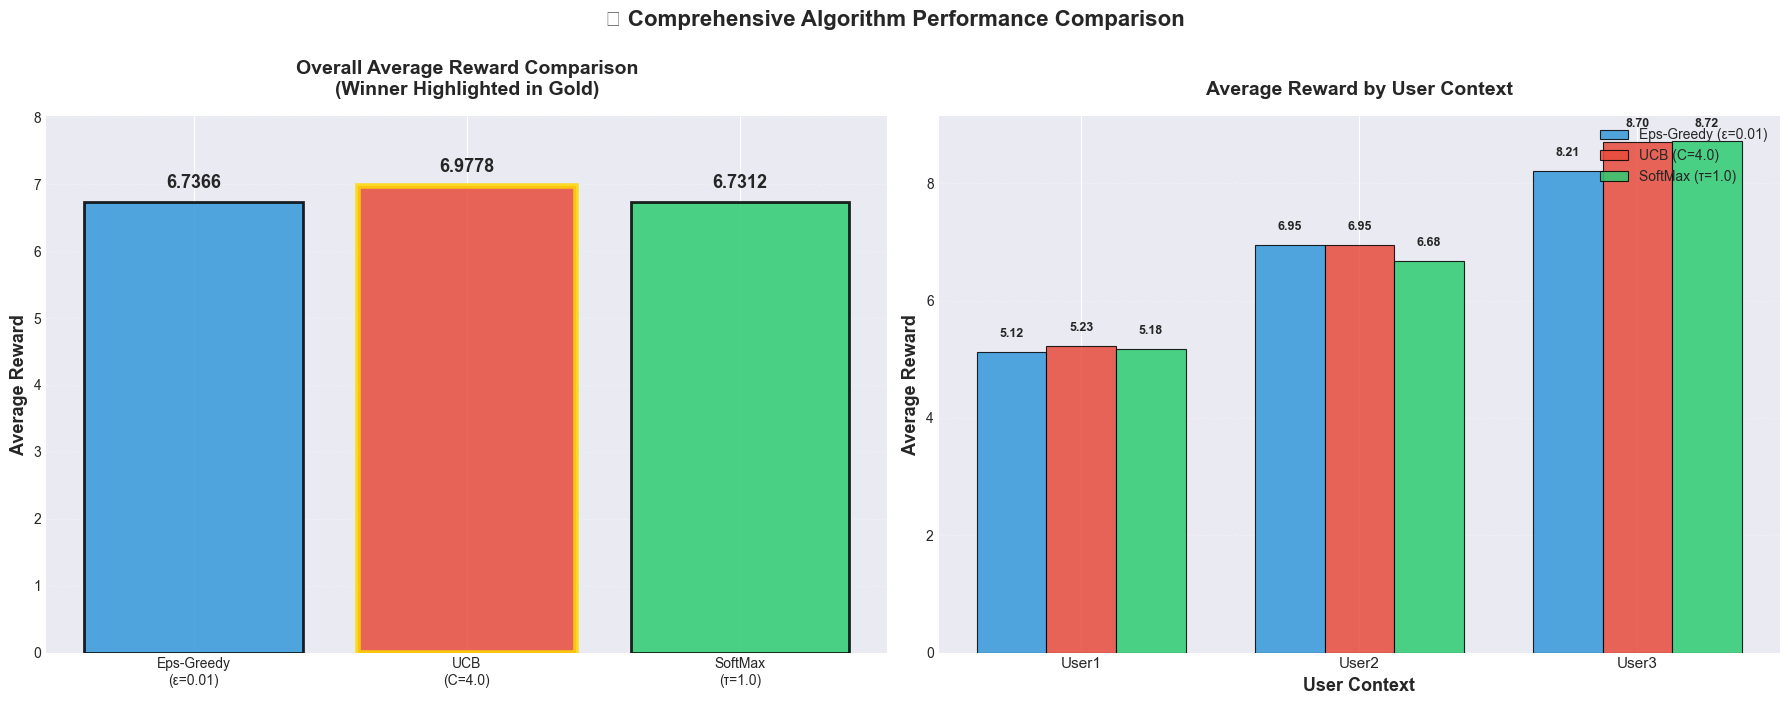

In [157]:
# Comparative Plot 2: Side-by-side Bar Chart Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Left plot: Overall average rewards
algo_names = [f'Eps-Greedy\n(ε={best_eps})', f'UCB\n(C={best_c})', f'SoftMax\n(τ={best_tau})']
algo_rewards = [eps_avg_rewards[best_eps], ucb_avg_rewards[best_c], softmax_avg_rewards[best_tau]]
colors = ['#3498db', '#e74c3c', '#2ecc71']

bars = ax1.bar(algo_names, algo_rewards, color=colors, alpha=0.85, 
               edgecolor='black', linewidth=2)

# Highlight the winner with gold border
best_idx = algo_rewards.index(max(algo_rewards))
bars[best_idx].set_edgecolor('gold')
bars[best_idx].set_linewidth(4)

# Add value labels
for bar, val in zip(bars, algo_rewards):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.15,
            f'{val:.4f}', ha='center', va='bottom',
            fontsize=13, fontweight='bold')

ax1.set_title('Overall Average Reward Comparison\n(Winner Highlighted in Gold)', 
              fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('Average Reward', fontsize=13, fontweight='bold')
ax1.set_ylim(0, max(algo_rewards) * 1.15)
ax1.grid(True, alpha=0.2, axis='y', linestyle='--')
ax1.set_axisbelow(True)

# Right plot: Rewards by context
contexts = user_types
x = np.arange(len(contexts))
width = 0.25

# Calculate context-specific rewards
eps_ctx_rewards = [np.mean(results_eps[best_eps][i]) for i in range(3)]
ucb_ctx_rewards = [np.mean(results_ucb[best_c][i]) for i in range(3)]
softmax_ctx_rewards = [np.mean(results_soft[best_tau][i]) for i in range(3)]

bars1 = ax2.bar(x - width, eps_ctx_rewards, width, 
                label=f'Eps-Greedy (ε={best_eps})', 
                color='#3498db', alpha=0.85, edgecolor='black', linewidth=0.8)
bars2 = ax2.bar(x, ucb_ctx_rewards, width, 
                label=f'UCB (C={best_c})', 
                color='#e74c3c', alpha=0.85, edgecolor='black', linewidth=0.8)
bars3 = ax2.bar(x + width, softmax_ctx_rewards, width, 
                label=f'SoftMax (τ={best_tau})', 
                color='#2ecc71', alpha=0.85, edgecolor='black', linewidth=0.8)

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.2,
                f'{height:.2f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

ax2.set_title('Average Reward by User Context', 
              fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('User Context', fontsize=13, fontweight='bold')
ax2.set_ylabel('Average Reward', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(contexts, fontsize=11)
ax2.legend(fontsize=10, loc='upper right', framealpha=0.95)
ax2.grid(True, alpha=0.2, axis='y', linestyle='--')
ax2.set_axisbelow(True)

plt.suptitle('🏆 Comprehensive Algorithm Performance Comparison', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 5.4 Recommendation Engine

Build an end-to-end recommendation system that:
1. Takes user features as input
2. Predicts user context (User1/User2/User3)
3. Selects optimal news category using trained bandit
4. Samples a specific article from that category

In [165]:
# raining final bandits for recommendation (using best hyperparameters)
final_bandits = [UCB(c=4.0) for _ in range(3)]

#Quick training run
for t in range(5000):
    ctx_idx = np.random.randint(0, 3)
    action = final_bandits[ctx_idx].select_action()
    global_arm = get_global_arm(ctx_idx, action)
    reward = env_sampler.sample(global_arm)
    final_bandits[ctx_idx].update(action, reward)

print("\nLearned Q-values for each context:")
for i, bandit in enumerate(final_bandits):
    user_label = le_target.inverse_transform([i])[0]
    print(f"\n{user_label}:")
    for cat_idx, q_val in enumerate(bandit.q):
        print(f"  {inv_cat_mapping[cat_idx]}: {q_val:.4f}")


Learned Q-values for each context:

User1:
  ENTERTAINMENT: -6.3646
  EDUCATION: 5.2643
  TECH: -2.6010
  CRIME: -8.6301

User2:
  ENTERTAINMENT: -3.9211
  EDUCATION: 6.9656
  TECH: 3.6470
  CRIME: 4.8453

User3:
  ENTERTAINMENT: 2.9231
  EDUCATION: -4.2870
  TECH: 4.4278
  CRIME: 8.7103


In [166]:
#Defining a fn to recommend news 
def recommend_news(user_attributes):
    """
    Recommend news article for a given user
    
    Args:
        user_attributes: dict or Series with user features
        
    Returns:
        (user_context, category_name, article_headline, article_link)
    """
    # 1. Preprocessing input
    input_df = pd.DataFrame([user_attributes])
    input_encoded = input_df.copy()
    
    #Filling numeric missing values with 0
    num_cols = input_encoded.select_dtypes(include=[np.number]).columns
    input_encoded[num_cols] = input_encoded[num_cols].fillna(0)
    
    #Encoding categorical features
    for col, le in encoders.items():
        if col in input_encoded:
            val = str(input_encoded[col].iloc[0])
            if val in le.classes_:
                input_encoded[col] = le.transform([val])
            else:
                input_encoded[col] = 0  # Default for unseen values
    
    #Aligning columns with training data
    for col in X_train.columns:
        if col not in input_encoded.columns:
            input_encoded[col] = 0
    input_encoded = input_encoded[X_train.columns]
    
    #Scaling numeric features (classifier was trained on scaled data!)
    numeric_cols = input_encoded.select_dtypes(include=[np.number]).columns.tolist()
    input_encoded[numeric_cols] = scaler.transform(input_encoded[numeric_cols])
    
    # 2. Predict user context
    user_class_idx = user_classifier.predict(input_encoded)[0]
    user_class_label = le_target.inverse_transform([user_class_idx])[0]
    
    # 3. Select news category using trained bandit (greedy - best action)
    chosen_arm = np.argmax(final_bandits[user_class_idx].q)
    chosen_category = inv_cat_mapping[chosen_arm]
    
    # 4. Sample article from chosen category
    candidates = news_df_filtered[news_df_filtered['category'] == chosen_category]
    if not candidates.empty:
        article = candidates.sample(1, random_state=np.random.randint(10000)).iloc[0]
        return user_class_label, chosen_category, article['headline'], article['link']
    else:
        return user_class_label, chosen_category, "No Article Found", "#"


### Test Recommendation Engine

In [167]:
# Get predictions on test set for visualization
test_pred_labels = user_classifier.predict(X_test_final)
test_pred_labels = le_target.inverse_transform(test_pred_labels)
unique_preds, pred_counts = np.unique(test_pred_labels, return_counts=True)

print(f"Test Set Predictions (n={len(test_pred_labels)}):")
for label, count in zip(unique_preds, pred_counts):
    pct = (count / len(test_pred_labels)) * 100
    print(f"  {label}: {count:4d} users ({pct:5.1f}%)")

Test Set Predictions (n=2000):
  User1:  680 users ( 34.0%)
  User2:  740 users ( 37.0%)
  User3:  580 users ( 29.0%)


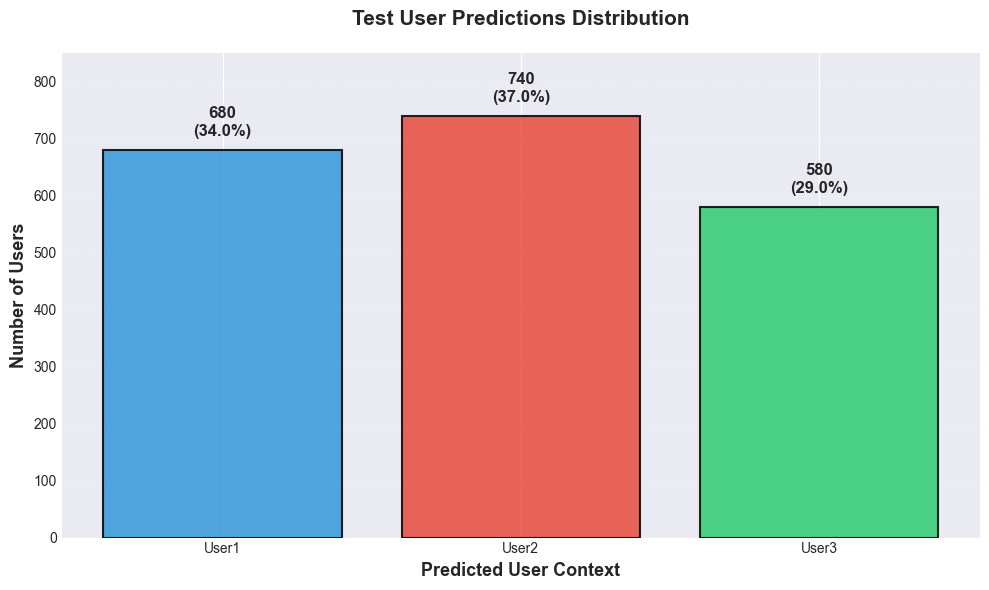

In [168]:
# Plot 1: Test User Prediction Distribution
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#3498db', '#e74c3c', '#2ecc71']
bars = ax.bar(unique_preds, pred_counts, color=colors, alpha=0.85, 
              edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar, count in zip(bars, pred_counts):
    height = bar.get_height()
    pct = (count / len(test_pred_labels)) * 100
    ax.text(bar.get_x() + bar.get_width()/2., height + 20,
            f'{count}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Test User Predictions Distribution', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Predicted User Context', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Users', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(pred_counts) * 1.15)
ax.grid(True, alpha=0.2, axis='y', linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

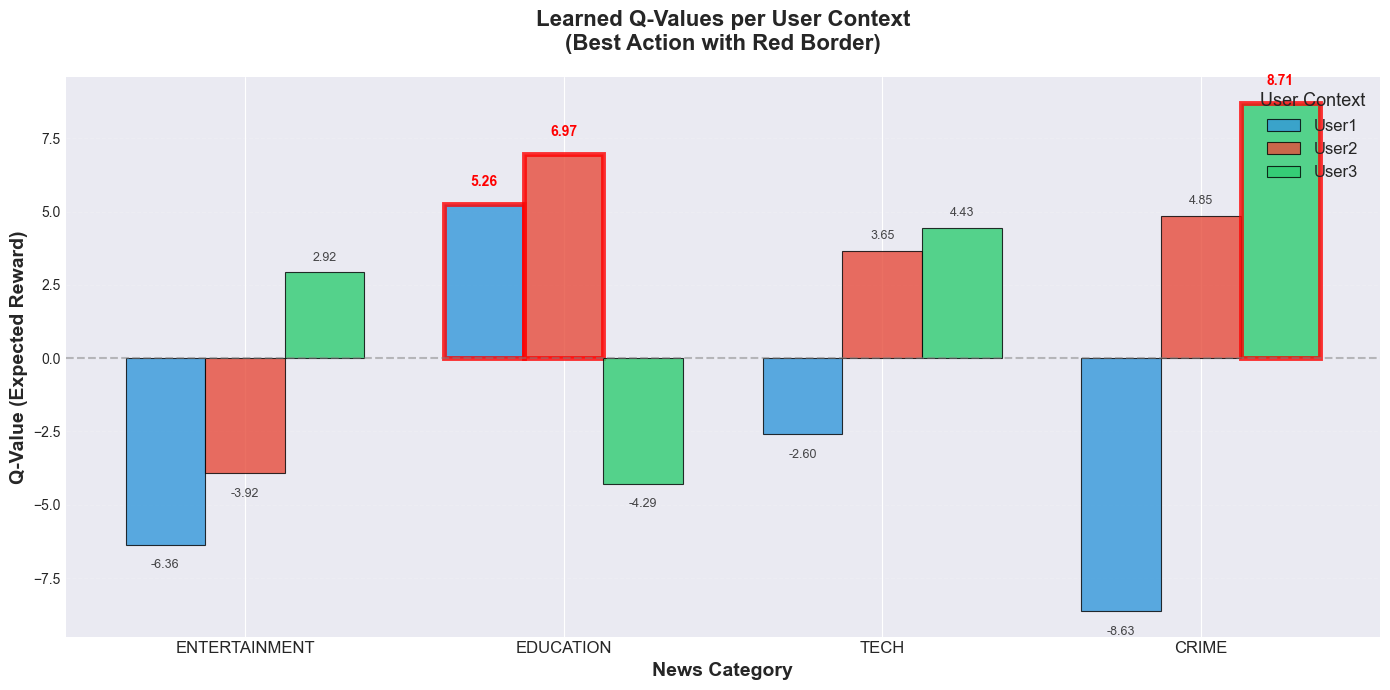

In [169]:
# Plot 2: Learned Q-Values with Better Layout
fig, ax = plt.subplots(figsize=(14, 7))

categories = ['ENTERTAINMENT', 'EDUCATION', 'TECH', 'CRIME']
user_types = le_target.classes_
n_categories = len(categories)
n_users = len(user_types)

# Use wider bars with better spacing
x = np.arange(n_categories)
width = 0.25
colors = ['#3498db', '#e74c3c', '#2ecc71']

# Create grouped bars
for i, user_type in enumerate(user_types):
    q_values = final_bandits[i].q
    offset = (i - 1) * width
    bars = ax.bar(x + offset, q_values, width, 
                  label=user_type, color=colors[i], alpha=0.8,
                  edgecolor='black', linewidth=0.8)
    
    # Highlight best action with red border
    best_idx = np.argmax(q_values)
    bars[best_idx].set_edgecolor('red')
    bars[best_idx].set_linewidth(3.5) 
    
    # Add value labels on bars
    for j, (bar, val) in enumerate(zip(bars, q_values)):
        if j == best_idx:  # Highlight best value
            ax.text(bar.get_x() + bar.get_width()/2., val + 0.5,
                   f'{val:.2f}', ha='center', va='bottom', 
                   fontsize=10, fontweight='bold', color='red')
        else:
            ax.text(bar.get_x() + bar.get_width()/2., val + 0.3 if val > 0 else val - 0.5,
                   f'{val:.2f}', ha='center', va='bottom' if val > 0 else 'top',
                   fontsize=9, color='black', alpha=0.7)

ax.set_title('Learned Q-Values per User Context\n(Best Action with Red Border)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('News Category', fontsize=14, fontweight='bold')
ax.set_ylabel('Q-Value (Expected Reward)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=12)
ax.legend(title='User Context', fontsize=12, title_fontsize=13, 
          loc='upper right', framealpha=0.95)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1.5, alpha=0.5)
ax.grid(True, alpha=0.15, axis='y', linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [170]:
# Test with users from test set
print("=" * 80)
print("RECOMMENDATION ENGINE TEST")
print("=" * 80)

for i in range(min(100, len(test_users_clean))):
    sample_user = test_users_clean.iloc[i]
    user_context, category, headline, link = recommend_news(sample_user)
    
    print(f"\n[Test User {i+1}]")
    print(f"  User ID: {sample_user['user_id']}")
    print(f"  Predicted Context: {user_context}")
    print(f"  Recommended Category: {category}")
    print(f"  Article: {headline[:80]}...")
    print(f"  Link: {link}")

print("\n" + "=" * 80)

RECOMMENDATION ENGINE TEST

[Test User 1]
  User ID: U4058
  Predicted Context: User2
  Recommended Category: EDUCATION
  Article: Exercising Restraint in Schools...
  Link: https://www.huffingtonpost.com/entry/exercising-restraint_b_5695227.html

[Test User 2]
  User ID: U1118
  Predicted Context: User1
  Recommended Category: EDUCATION
  Article: Exclusive: Data Show Charter School Students Graduating From College At Three To...
  Link: https://www.huffingtonpost.com/entry/exclusive-data-show-charter-school-students-graduating_us_5979f910e4b0c69ef705260d

[Test User 3]
  User ID: U6555
  Predicted Context: User1
  Recommended Category: EDUCATION
  Article: Fake News, Social Media and the Downfall of the U.S....
  Link: https://www.huffingtonpost.com/entry/fake-news-social-media-and-the-downfall-of-the-us_us_586d0508e4b04d7df167d883

[Test User 4]
  User ID: U9170
  Predicted Context: User1
  Recommended Category: EDUCATION
  Article: Should Schools Ban Cellphones?...
  Link: https://